# Iteration 1: A simple model with one type of unplanned admission

In order to simplify the model, we will first assume that patients only arrive from one source – we will take this to be A&E and use the given interrarival times and length of stay for this pathway.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy
import warnings
from scipy.stats import t
from sim_tools.distributions import Exponential, Lognormal

## Model Classes

We will use a similar object orientated approach for healthcare modelling in SimPy to the one recommended in the [HSMA little book of DES](https://des.hsma.co.uk/), making use of four main classes

* `CritCarePt`, a class used to store information about the patients in the system.
* `CritCareUnit`, a class representing the CCU system being modelled, in which the SimPy environment and generators are kept.
* `ScenarioTrial`, a class representing a batch of runs of a simulation with specific parameter settings.
* `Experiment`, a class representing an experiment in which multiple different scenarios are compared.

## The `CritCarePt` class

Let's start by coding a simple class representing patients who are admitted to the unit.

In [2]:
class CritCarePt:
    """
    Represents a patient in the system.

    Attributes
    ----------
    id : int
        Unique patient identifier.
    queue_time : float
        Time the patient spent waiting for a bed in hours.
    time_in_ccu : float
        Actual time the patient spent occupying a bed during the simulation.
    """
    def __init__(self, p_id):
        """
        Initialise a new patient.
        """
        self.id = p_id
        self.queue_time = 0
        self.time_in_ccu = 0

## The `CritCareUnit` class

We now move on to the `CritCareUnit` class.

In [3]:
class CritCareUnit:
    """
    Discrete event simulation of the system.

    Attributes
    ----------
    random_seed : int
        Seed used to reproduce a specific run.
    mean_ia : float
        Mean inter-arrival time between patients in hours.
    mean_len_stay : float
        Mean length of stay for a patient in hours.
    stdev_len_stay : float
        Standard deviation of the length-of-stay distribution.
    time_to_clean : float
        The time taken for intensive cleaning of a bed in hours.
    num_beds : int
        Number of CCU beds available.
    sim_duration : float
        Duration of the simulation after the warm-up period.
    warm_up : float
        Warm-up period duration in hours
        (results collected only after this time).
    first_patient_post_warm_up : int
        The identifier of the first patient to be included in results
        calculations following the warm-up period.
    env : simpy.Environment
        The SimPy simulation environment.
    patient_counter : int
        Running count of patients who have arrived.
    sim_admitted_pts : list of CritCarePt
        Patient objects created after the warm-up period.
    bed : simpy.Resource
        SimPy resource representing the pool of beds.
    results_df : pandas.DataFrame
        Per-patient results (Queue Time, Length of Stay).
    sampled_inter_arrival_times : list
        The sampled interrarrival times during the simulation.
    sampled_stay_durations : list
        The sampled lengths of stay during the simulation.
    mean_queue_time : float
        Average queue time across all post-warm-up patients.
    bed_utilisation : float
        Average bed utilisation as a percentage.
    bed_occupancy : float
        Average number of beds occupied.
    inter_arrival_dist : Exponential
        Exponential distribution used to sample inter-arrival times.
    len_stay_dist : Lognormal
        Lognormal distribution used to sample lengths of stay.
    """
    def __init__(self, random_seed, mean_inter_arrival_time,
                 mean_length_of_stay, length_of_stay_std_dev, time_to_clean,
                 number_of_beds, simulation_duration, warm_up_period):
        """
        Initialise the simulation model.
        """
        self.random_seed = random_seed
        self.mean_ia = mean_inter_arrival_time
        self.mean_len_stay = mean_length_of_stay
        self.stdev_len_stay = length_of_stay_std_dev
        self.clean_time = time_to_clean
        self.num_beds = number_of_beds
        self.sim_duration = simulation_duration
        self.warm_up = warm_up_period
        self.env = simpy.Environment()
        self.patient_counter = 0
        self.first_patient_post_warm_up = 0
        self.sim_admitted_pts = []
        self.bed = simpy.Resource(self.env, capacity=self.num_beds)
        self.results_df = pd.DataFrame()
        self.results_df["Patient ID"] = [1]
        self.results_df["Queue Time"] = [0.0]
        self.results_df["Length of Stay"] = [0.0]
        self.results_df.set_index("Patient ID", inplace=True)
        self.sampled_inter_arrival_times = []
        self.sampled_stay_durations = []
        self.mean_queue_time = 0.0
        self.bed_utilisation = 0.0
        self.bed_occupancy = 0.0
        ss = np.random.SeedSequence(self.random_seed)
        seeds = ss.spawn(2)
        self.inter_arrival_dist = Exponential(mean=mean_inter_arrival_time,
                                              random_seed=seeds[0])
        self.len_stay_dist = Lognormal(mean=mean_length_of_stay,
                                       stdev=length_of_stay_std_dev,
                                       random_seed=seeds[1])

    def generate_patient_referrals(self):
        """
        Generate arriving patients.

        Each iteration increments the patient counter, spawns an admission
        process for the new patient, then waits for a
        sampled inter-arrival time before looping.
        """
        while True:
            self.patient_counter += 1
            p = CritCarePt(self.patient_counter)
            self.env.process(self.admit_unit(p))
            sampled_inter = self.inter_arrival_dist.sample()
            if self.env.now > self.warm_up:
                self.sampled_inter_arrival_times.append(sampled_inter)
            yield self.env.timeout(sampled_inter)

    def admit_unit(self, patient):
        """
        Models a single patient's admission.

        The patient queues for a bed, occupies it for a sampled length of
        stay, and then releases it.  Results are only recorded after the
        warm-up period has elapsed.
        """
        start_q_bed = self.env.now
        with self.bed.request() as req:
            yield req
            end_q_bed = self.env.now
            patient.queue_time = end_q_bed - start_q_bed
            sampled_len_stay = self.len_stay_dist.sample()
            sim_time_remain = self.sim_duration + self.warm_up - self.env.now
            len_stay_before_end_sim = min(sampled_len_stay, sim_time_remain)
            patient.time_in_ccu = len_stay_before_end_sim
            if self.env.now > self.warm_up:
                self.results_df.at[patient.id, "Queue Time"] = (
                    patient.queue_time)
                self.results_df.at[patient.id, "Length of Stay"] = (
                    sampled_len_stay)
                self.sim_admitted_pts.append(patient)
                self.sampled_stay_durations.append(sampled_len_stay)
            yield self.env.timeout(sampled_len_stay + self.clean_time)

    def audit_bed_utilisation(self):
        """
        Calculate bed utilisation as a percentage.

        Utilisation is computed as the total occupied bed-time divided by
        the total available bed-time (beds × simulation duration), expressed
        as a percentage.
        """
        treatment_durations = [i.time_in_ccu for i in self.sim_admitted_pts]
        return (sum(treatment_durations) * 100
                / (self.num_beds * self.sim_duration))

    def calculate_run_results(self):
        """
        Aggregate per-run summary statistics.

        Removes the placeholder row from results_df, then computes
        mean queue time, mean length of stay, and bed utilisation for the
        run.
        """
        self.results_df.drop([1], inplace=True)
        self.first_patient_post_warm_up = min(self.results_df.index)
        self.mean_queue_time = self.results_df["Queue Time"].mean()
        self.bed_utilisation = self.audit_bed_utilisation()
        self.bed_occupancy = self.bed_utilisation * self.num_beds / 100

    def run(self):
        """
        Execute the simulation.

        Registers the patient-arrival generator with the SimPy environment,
        runs the simulation for warm_up + sim_duration hours, then
        calculates summary results.
        """
        self.env.process(self.generate_patient_referrals())
        self.env.run(until=(self.sim_duration + self.warm_up))
        self.calculate_run_results()

Let's see what the results of one run of the model looks like. Here we'll set the number of beds to be eight. There will be fewer referrals than in reality because patients arriving from anywhere other than A&E are not accounted for.

In [4]:
eight_bed_model = CritCareUnit(
    random_seed=42,
    mean_inter_arrival_time=22.72,
    mean_length_of_stay=128.79,
    length_of_stay_std_dev=267.51,
    time_to_clean=5,
    number_of_beds=8,
    simulation_duration=(24 * 365),
    warm_up_period=(24 * 31)
)
eight_bed_model.run()

In [5]:
print(f"The mean wait time was: {eight_bed_model.mean_queue_time} hours"
      + "\nThe average number of beds occupied was:",
      eight_bed_model.bed_occupancy)

The mean wait time was: 27.753101682924463 hours
The average number of beds occupied was: 6.198756964969


In [6]:
eight_bed_model.results_df.head(20)

,Queue Time,Length of Stay
Patient ID,,
30,0.000000,142.764863
31,0.000000,277.182017
32,0.000000,181.627649
33,0.000000,101.142900
34,0.000000,24.088303
35,28.122845,15.986660
36,7.145014,19.868483
37,7.509503,9.119024
38,8.176943,380.547368


Let's also sense-check the sampled inter-arrival and length of stay distributions.

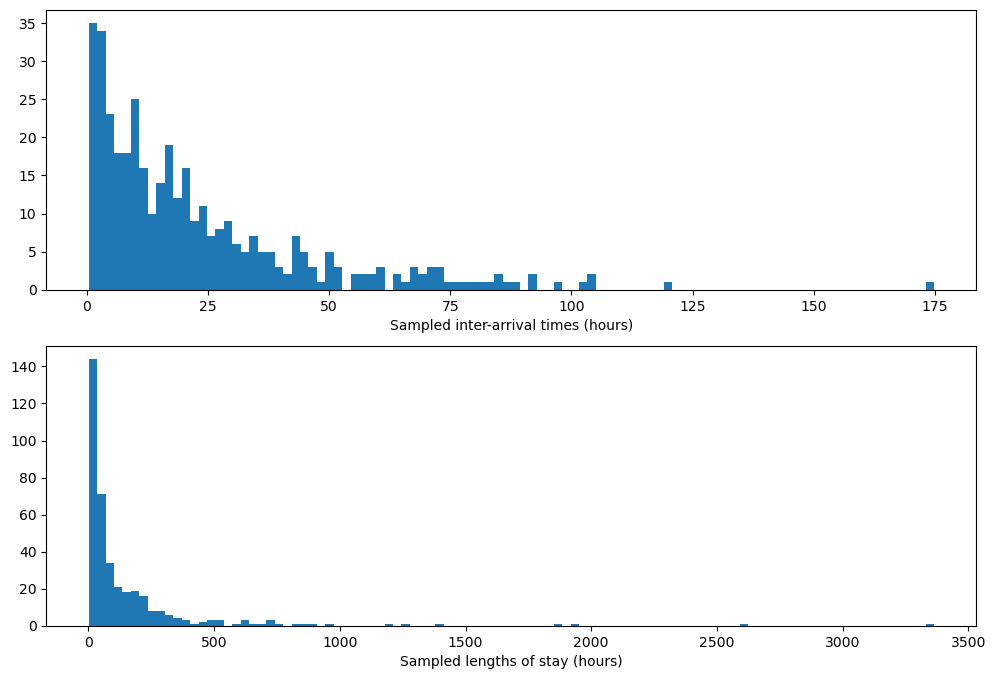

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
_ = ax1.hist(eight_bed_model.sampled_inter_arrival_times, bins=100)
_ = ax1.set_xlabel("Sampled inter-arrival times (hours)")
_ = ax2.hist(eight_bed_model.sampled_stay_durations, bins=100)
_ = ax2.set_xlabel("Sampled lengths of stay (hours)")

The model seems to be working as expected. Let's proceeed to coding the `Scenario Trial` class.

## The `ScenarioTrial` class

Let's implement a `ScenarioTrial` class which will allow us to run multiple replications of the simulation.

In [8]:
class ScenarioTrial:
    """
    Runs multiple replications of a simulation of the CCU system for a fixed
    scenario and tracks convergence via confidence intervals. The minimum
    number of replications required to reach a desired precision in both the
    mean queue time and bed utilisation metrics is also determined.

    Attributes
    ----------
    num_reps : int
        Number of simulation replications to run.
    mean_ia : float
        Mean inter-arrival time in hours passed to each replication.
    mean_len_stay : float
        Mean length of stay in hours passed to each replication.
    stdev_len_stay : float
        Standard deviation of length of stay.
    time_to_clean : float
        The time taken for intensive cleaning of a bed in hours.
    num_beds : int
        Number of beds passed to each replication.
    sim_duration : float
        Simulation duration per replication in hours.
    warm_up : float
        Warm-up period per replication in hours.
    alpha : float
        Significance level for confidence intervals (default 0.05).
    precision : float
        Desired relative precision as a proportion (default 0.05 = 5%).
    ci_fig_size : tuple
        Figure size used by the confidence-interval plot methods.
    min_reps_wait : int
        Minimum replications to reach precision for mean queue time
        (-1 if not reached).
    min_reps_util : int
        Minimum replications to reach precision for bed utilisation
        (-1 if not reached).
    min_reps : int
        Overall minimum replications required (-1 if not reached).
    run_results_dict : dict
        Maps replication labels to their per-patient results DataFrames.
    trial_results_df : pandas.DataFrame
        One row per replication with mean queue time, bed utilisation,
        and occupancy.
    overall_results : pandas.DataFrame
        The overall results of the trial.
    var_wait_df : pandas.DataFrame
        Running statistics (mean, CI bounds, % deviation) for queue time.
    var_util_df : pandas.DataFrame
        Running statistics for bed utilisation.
    var_beds_df : pandas.DataFrame
        Running statistics for bed occupancy.
    """
    def __init__(self, number_of_reps, mean_inter_arrival_time,
                 mean_length_of_stay, length_of_stay_std_dev,
                 number_of_beds, time_to_clean,
                 simulation_duration, warm_up_period,
                 ci_alpha=0.05, desired_precision=0.05):
        self.num_reps = number_of_reps
        self.mean_ia = mean_inter_arrival_time
        self.mean_len_stay = mean_length_of_stay
        self.stdev_len_stay = length_of_stay_std_dev
        self.clean_time = time_to_clean
        self.num_beds = number_of_beds
        self.sim_duration = simulation_duration
        self.warm_up = warm_up_period
        self.alpha = ci_alpha
        self.precision = desired_precision
        self.min_reps_wait = 0
        self.min_reps_util = 0
        self.min_reps_beds = 0
        self.min_reps = 0
        self.run_results_dict = {}
        self.trial_results_df = pd.DataFrame()
        self.trial_results_df["Mean Wait for a Bed"] = [0.0]
        self.trial_results_df["Bed Utilisation"] = [0.0]
        self.trial_results_df["Bed Occupancy"] = [0.0]
        self.overall_results_df = pd.DataFrame()
        self.var_wait_df = pd.DataFrame()
        self.var_util_df = pd.DataFrame()
        self.var_beds_df = pd.DataFrame()

    def run_trial(self):
        """
        Execute all replications, populate trial_results_df, and compute
        running confidence intervals.

        For each replication a new CritCareUnit object is instantiated,
        run, and its results stored.  The index of trial_results_df is
        set to 1-based replication numbers.

        After running every replication, cumulative means, running variances,
        standard errors, and confidence intervals half-widths for mean queue
        time, bed utilisation, and bed occupancy are computed.

        The min_reps_wait, min_reps_util, min_reps_beds and min_reps attributes
        are set to the first replication index at which the relative deviation
        falls below the desired precision. A warning is issued for any metric
        that never reaches the desired precision.
        """
        for run in range(self.num_reps):
            ccu_model = CritCareUnit(
                random_seed=run,
                mean_inter_arrival_time=self.mean_ia,
                mean_length_of_stay=self.mean_len_stay,
                length_of_stay_std_dev=self.stdev_len_stay,
                time_to_clean=self.clean_time,
                number_of_beds=self.num_beds,
                simulation_duration=self.sim_duration,
                warm_up_period=self.warm_up
            )
            ccu_model.run()
            run_results = ccu_model.results_df
            self.run_results_dict[f"Replication {run+1}"] = run_results
            self.trial_results_df.loc[run, "Mean Wait for a Bed"] \
                = [ccu_model.mean_queue_time]
            self.trial_results_df.loc[run, "Bed Utilisation"] \
                = [ccu_model.bed_utilisation]
            self.trial_results_df.loc[run, "Bed Occupancy"] \
                = [ccu_model.bed_occupancy]
        self.trial_results_df.index = np.arange(1, self.num_reps + 1)
        self.trial_results_df.index.name = "Replication"

        mean_wait = self.trial_results_df["Mean Wait for a Bed"].mean()
        std_wait = self.trial_results_df["Mean Wait for a Bed"].std()
        mean_util = self.trial_results_df["Bed Utilisation"].mean()
        std_util = self.trial_results_df["Bed Utilisation"].std()
        mean_beds = self.trial_results_df["Bed Occupancy"].mean()
        std_beds = self.trial_results_df["Bed Occupancy"].std()

        self.overall_results_df = pd.DataFrame({
            "Mean": [mean_wait, mean_util, mean_beds],
            "Standard Deviation": [std_wait, std_util, std_beds]
        })

        self.overall_results_df.index = ["Mean Wait for a Bed",
                                         "Bed Utilisation",
                                         "Bed Occupancy"]

        degrees_freedom = self.num_reps - 1
        t_value = t.ppf(1 - (self.alpha / 2),  degrees_freedom)

        mean_wait_list = self.trial_results_df["Mean Wait for a Bed"].tolist()
        cumulative_mean_wait = [mean_wait_list[0]]
        running_var_wait = [0.0]
        for i in range(1, self.num_reps):
            cumulative_mean_wait.append(cumulative_mean_wait[i - 1]
                                        + (mean_wait_list[i]
                                           - cumulative_mean_wait[i - 1])
                                        / (i + 1))
            running_var_wait.append(running_var_wait[i - 1]
                                    + (mean_wait_list[i]
                                       - cumulative_mean_wait[i - 1])
                                    * (mean_wait_list[i]
                                       - cumulative_mean_wait[i]))
        with np.errstate(divide='ignore', invalid='ignore'):
            running_std_wait = np.sqrt(running_var_wait
                                       / np.arange(self.num_reps))
        with np.errstate(divide='ignore', invalid='ignore'):
            std_error_wait = running_std_wait / np.sqrt(np.arange(1,
                                                                  self.num_reps
                                                                  + 1))
        half_width_wait = t_value * std_error_wait
        upper_wait = cumulative_mean_wait + half_width_wait
        lower_wait = cumulative_mean_wait - half_width_wait
        with np.errstate(divide='ignore', invalid='ignore'):
            deviation_wait = (half_width_wait / cumulative_mean_wait) * 100
        self.var_wait_df = pd.DataFrame([mean_wait_list, cumulative_mean_wait,
                                         running_std_wait,
                                         lower_wait, upper_wait,
                                         deviation_wait]).T
        self.var_wait_df.columns = ["Mean", "Cumulative Mean",
                                    "Standard Deviation", "Lower Interval",
                                    "Upper Interval", "% Deviation"]
        self.var_wait_df.index = np.arange(1, self.num_reps + 1)
        self.var_wait_df.index.name = "Replications"

        wait_reps_below_precision = self.var_wait_df.loc[
            self.var_wait_df["% Deviation"]
            <= self.precision*100].index.tolist()
        if len(wait_reps_below_precision) == 0:
            message = "WARNING: The replications do not reach the desired " \
                + "precision for mean wait for a bed."
            warnings.warn(message)
            self.min_reps_wait = -1
        else:
            self.min_reps_wait = wait_reps_below_precision[0]

        mean_util_list = self.trial_results_df[
            "Bed Utilisation"].tolist()
        cumulative_mean_util = [mean_util_list[0]]
        running_var_util = [0.0]
        for i in range(1, self.num_reps):
            cumulative_mean_util.append(cumulative_mean_util[i - 1]
                                        + (mean_util_list[i]
                                           - cumulative_mean_util[i - 1])
                                        / (i+1))
            running_var_util.append(running_var_util[i - 1]
                                    + (mean_util_list[i]
                                       - cumulative_mean_util[i - 1])
                                    * (mean_util_list[i]
                                       - cumulative_mean_util[i]))
        with np.errstate(divide="ignore", invalid="ignore"):
            running_std_util = np.sqrt(running_var_util
                                       / np.arange(self.num_reps))
        with np.errstate(divide="ignore", invalid="ignore"):
            std_error_util = running_std_util / np.sqrt(np.arange(1,
                                                                  self.num_reps
                                                                  + 1))
        half_width_util = t_value * std_error_util
        upper_util = cumulative_mean_util + half_width_util
        lower_util = cumulative_mean_util - half_width_util
        with np.errstate(divide="ignore", invalid="ignore"):
            deviation_util = (half_width_util / cumulative_mean_util) * 100
        self.var_util_df = pd.DataFrame([mean_util_list, cumulative_mean_util,
                                         running_std_util,
                                         lower_util, upper_util,
                                         deviation_util]).T
        self.var_util_df.columns = ["Mean", "Cumulative Mean",
                                    "Standard Deviation", "Lower Interval",
                                    "Upper Interval", "% Deviation"]
        self.var_util_df.index = np.arange(1, self.num_reps + 1)
        self.var_util_df.index.name = "Replications"

        util_reps_below_precision = self.var_util_df.loc[
            self.var_util_df["% Deviation"]
            <= self.precision * 100].index.tolist()
        if len(util_reps_below_precision) == 0:
            message = "WARNING: The replications do not reach the desired " \
                + "precision for bed utilisation."
            warnings.warn(message)
            self.min_reps_util = -1
        else:
            self.min_reps_util = util_reps_below_precision[0]

        mean_beds_list = self.trial_results_df[
            "Bed Occupancy"].tolist()
        cumulative_mean_beds = [mean_beds_list[0]]
        running_var_beds = [0.0]
        for i in range(1, self.num_reps):
            cumulative_mean_beds.append(cumulative_mean_beds[i - 1]
                                        + (mean_beds_list[i]
                                           - cumulative_mean_beds[i - 1])
                                        / (i + 1))
            running_var_beds.append(running_var_beds[i - 1]
                                    + (mean_beds_list[i]
                                       - cumulative_mean_beds[i - 1])
                                    * (mean_beds_list[i]
                                       - cumulative_mean_beds[i]))
        with np.errstate(divide='ignore', invalid='ignore'):
            running_std_beds = np.sqrt(running_var_beds
                                       / np.arange(self.num_reps))
        with np.errstate(divide='ignore', invalid='ignore'):
            std_error_beds = running_std_beds / np.sqrt(np.arange(1,
                                                                  self.num_reps
                                                                  + 1))
        half_width_beds = t_value * std_error_beds
        upper_beds = cumulative_mean_beds + half_width_beds
        lower_beds = cumulative_mean_beds - half_width_beds
        with np.errstate(divide='ignore', invalid='ignore'):
            deviation_beds = (half_width_beds / cumulative_mean_beds) * 100
        self.var_beds_df = pd.DataFrame([mean_beds_list, cumulative_mean_beds,
                                         running_std_beds,
                                         lower_beds, upper_beds,
                                         deviation_beds]).T
        self.var_beds_df.columns = ["Mean", "Cumulative Mean",
                                    "Standard Deviation", "Lower Interval",
                                    "Upper Interval", "% Deviation"]
        self.var_beds_df.index = np.arange(1, self.num_reps + 1)
        self.var_beds_df.index.name = "Replications"

        beds_reps_below_precision = self.var_wait_df.loc[
            self.var_beds_df["% Deviation"]
            <= self.precision*100].index.tolist()
        if len(beds_reps_below_precision) == 0:
            message = "WARNING: The replications do not reach the desired " \
                + "precision for bed occupancy."
            warnings.warn(message)
            self.min_reps_beds = -1
        else:
            self.min_reps_beds = beds_reps_below_precision[0]

        if self.min_reps_wait > 0 and self.min_reps_util > 0:
            self.min_reps = max(
                self.min_reps_wait,
                self.min_reps_util,
                self.min_reps_beds
            )
        else:
            self.min_reps = -1

    def plot_reps(self):
        """
        Plot cumulative mean and confidence intervals for all metrics.

        A vertical red dashed line marks the replication at which the
        desired precision is first achieved (if ever).
        """
        fig, axs = plt.subplots(3, figsize=(12, 12), sharex=True)

        self.var_wait_df[
            ["Cumulative Mean", "Lower Interval", "Upper Interval"]
        ].plot(ax=axs[0], legend=False)
        axs[0].grid(ls='--')
        axs[0].set_ylabel("Mean wait for a bed (hours)")
        if self.min_reps > 0:
            axs[0].axvline(x=self.min_reps_wait, ls='--', color='red')

        self.var_util_df[
            ["Cumulative Mean", "Lower Interval", "Upper Interval"]
        ].plot(ax=axs[1], legend=False)
        axs[1].grid(ls='--')
        axs[1].set_ylabel("Bed utilisation (%)")
        if self.min_reps > 0:
            axs[1].axvline(x=self.min_reps_wait, ls='--', color='red')

        self.var_beds_df[
            ["Cumulative Mean", "Lower Interval", "Upper Interval"]
        ].plot(ax=axs[2], legend=False)
        axs[2].grid(ls='--')
        axs[2].set_ylabel("Bed occupancy")
        if self.min_reps > 0:
            axs[2].axvline(x=self.min_reps_wait, ls='--', color='red')

        plt.setp(axs[0].get_xticklabels(), visible=False)
        plt.setp(axs[1].get_xticklabels(), visible=False)
        axs[2].set_xlabel("Replications")

        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center",
                   ncol=3, bbox_to_anchor=(0.5, -0.05))
        plt.tight_layout()

        return axs

To check this class is working, we will inspect the results of 1000 replications of our eight bed simulation.

In [9]:
eight_bed_trial = ScenarioTrial(
    number_of_reps=1000,
    mean_inter_arrival_time=22.72,
    mean_length_of_stay=128.79,
    length_of_stay_std_dev=267.51,
    time_to_clean=5,
    number_of_beds=8,
    simulation_duration=(24 * 365),
    warm_up_period=(24 * 31),
    desired_precision=0.1
)
eight_bed_trial.run_trial()

In [10]:
print("The minimum number of replications needed to reach " +
      f"{eight_bed_trial.precision * 100}% precision in mean wait time\n" +
      f"and mean bed utilisation/occupancy is: {eight_bed_trial.min_reps}")

The minimum number of replications needed to reach 10.0% precision in mean wait time
and mean bed utilisation/occupancy is: 806


In [11]:
eight_bed_trial.trial_results_df.head(20)

,Mean Wait for a Bed,Bed Utilisation,Bed Occupancy
Replication,,,
1,161.840595,78.086871,6.246950
2,24.892717,61.785457,4.942837
3,9.150827,64.244711,5.139577
4,9.010117,67.188352,5.375068
5,11.944536,59.232881,4.738630
6,7.787755,57.189372,4.575150
7,21.473604,70.940293,5.675223
8,32.253666,72.526360,5.802109
9,22.469223,71.437551,5.715004


In [12]:
eight_bed_trial.overall_results_df

,Mean,Standard Deviation
Mean Wait for a Bed,28.286913,39.709998
Bed Utilisation,67.481031,6.900090
Bed Occupancy,5.398482,0.552007


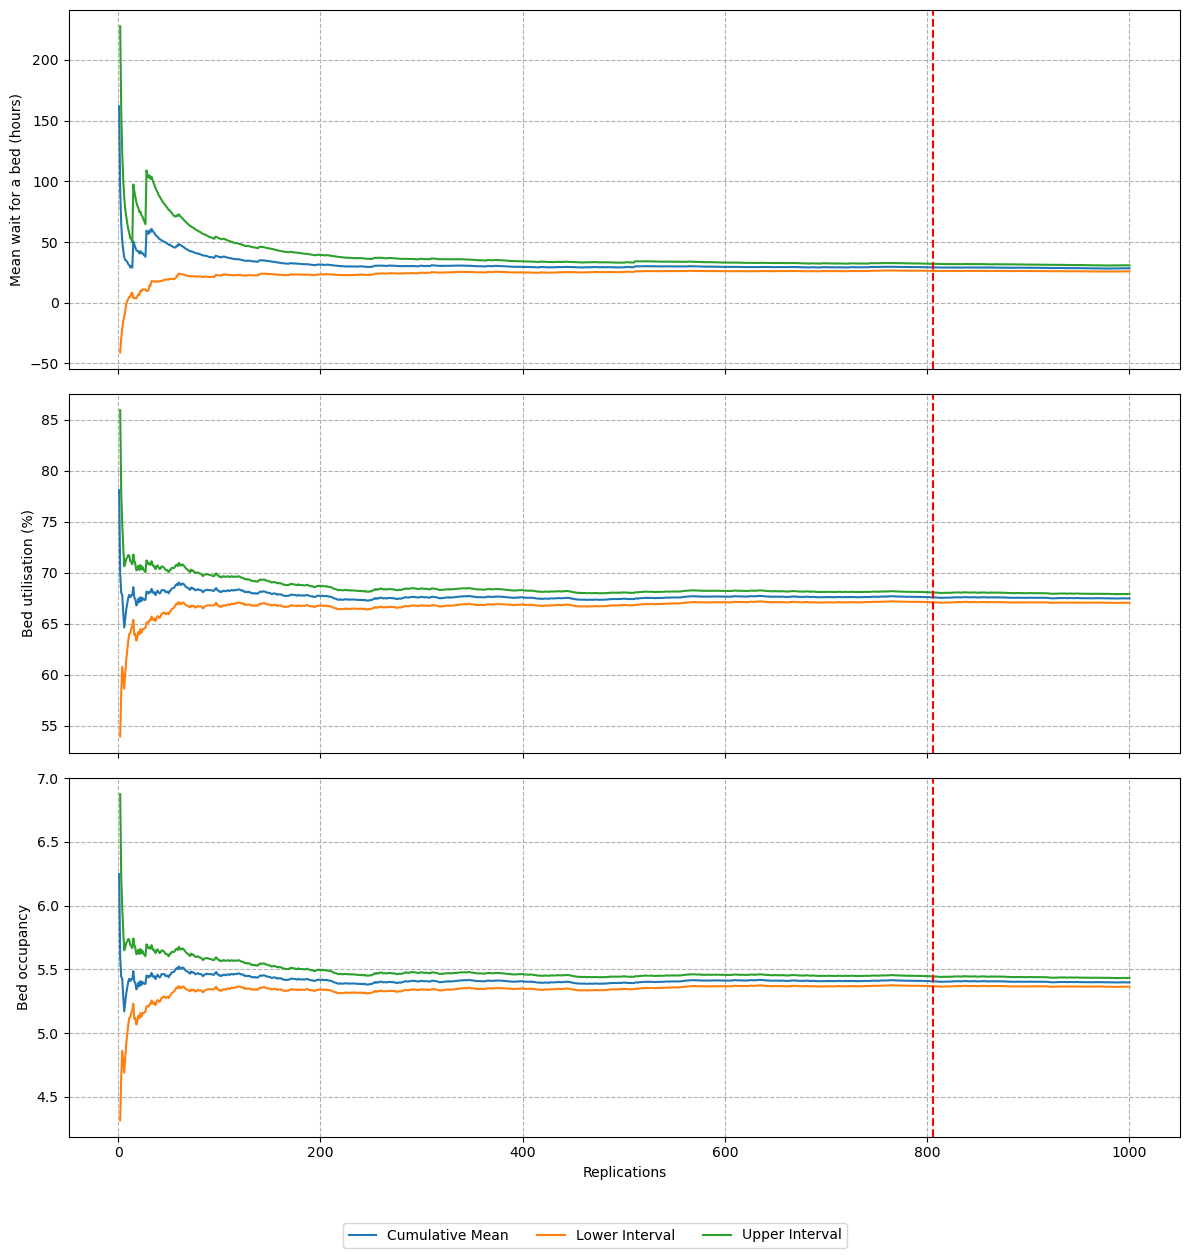

In [13]:
metrics_plot = eight_bed_trial.plot_reps()

## The `Experiment` class

Finally, we code an `Experiment` class which allows us to test scenarios with different numbers of beds.

For each experiment we will need a dictionary of parameters for each scenario.

In [14]:
scenario_names = ["Six Beds", "Eight Beds", "Ten Beds"]
scenarios_dict = {}

for i in range(3):
    i_dict = {
        "Number of Replications": 50,
        "Mean Inter-Arrival Time": 22.72,
        "Mean Length of Stay": 128.79,
        "Length of Stay Standard Deviation": 267.51,
        "Time to Clean": 5,
        "Number of Beds": 2 * i + 6,
        "Simulation Duration": (24 * 365),
        "Warm-Up Period": (24 * 31),
        "Desired Precision": 0.05
    }
    scenarios_dict[scenario_names[i]] = i_dict

Now let's code the class.

In [15]:
class Experiment:
    """
    Runs multiple replications of different scenarios.

    Attributes
    ----------
    scenario_params : dict
        Dictionary of dictionaries containing scenario parameters.
    trial_objects : dict
        Instances of ScenarioTrial for each different scenario.
    """
    def __init__(self, dictionary_of_scenarios):
        self.scenario_params = dictionary_of_scenarios
        self.trial_objects = {}
    def run_experiment(self):
        for scenario in self.scenario_params:
            variables = self.scenario_params[scenario]
            scenario_trial = ScenarioTrial(
                number_of_reps=variables["Number of Replications"],
                mean_inter_arrival_time=variables["Mean Inter-Arrival Time"],
                mean_length_of_stay=variables["Mean Length of Stay"],
                length_of_stay_std_dev=variables[
                    "Length of Stay Standard Deviation"
                    ],
                time_to_clean=variables["Time to Clean"],
                number_of_beds=variables["Number of Beds"],
                simulation_duration=variables["Simulation Duration"],
                warm_up_period=variables["Warm-Up Period"],
                desired_precision=variables["Desired Precision"]
            )
            print(f"Scenario: {scenario}\nStarting simulations...")
            scenario_trial.run_trial()
            print("Simulations complete.")
            self.trial_objects[scenario] = scenario_trial

Let's run the experiment, and compare the metrics for different numbers of beds.

In [16]:
beds_experiment = Experiment(scenarios_dict)
beds_experiment.run_experiment()

Scenario: Six Beds
Starting simulations...


/var/folders/_5/qhtrsq3x0s3786jzq_r0w4500000gn/T/ipykernel_1291/14921265.py:184: UserWarning: WARNING: The replications do not reach the desired precision for mean wait for a bed.
  warnings.warn(message)


Simulations complete.
Scenario: Eight Beds
Starting simulations...


/var/folders/_5/qhtrsq3x0s3786jzq_r0w4500000gn/T/ipykernel_1291/14921265.py:184: UserWarning: WARNING: The replications do not reach the desired precision for mean wait for a bed.
  warnings.warn(message)


Simulations complete.
Scenario: Ten Beds
Starting simulations...
Simulations complete.


/var/folders/_5/qhtrsq3x0s3786jzq_r0w4500000gn/T/ipykernel_1291/14921265.py:184: UserWarning: WARNING: The replications do not reach the desired precision for mean wait for a bed.
  warnings.warn(message)


Six Beds


,Mean,Standard Deviation
Mean Wait for a Bed,303.670179,320.36519
Bed Utilisation,85.959148,5.55916
Bed Occupancy,5.157549,0.33355


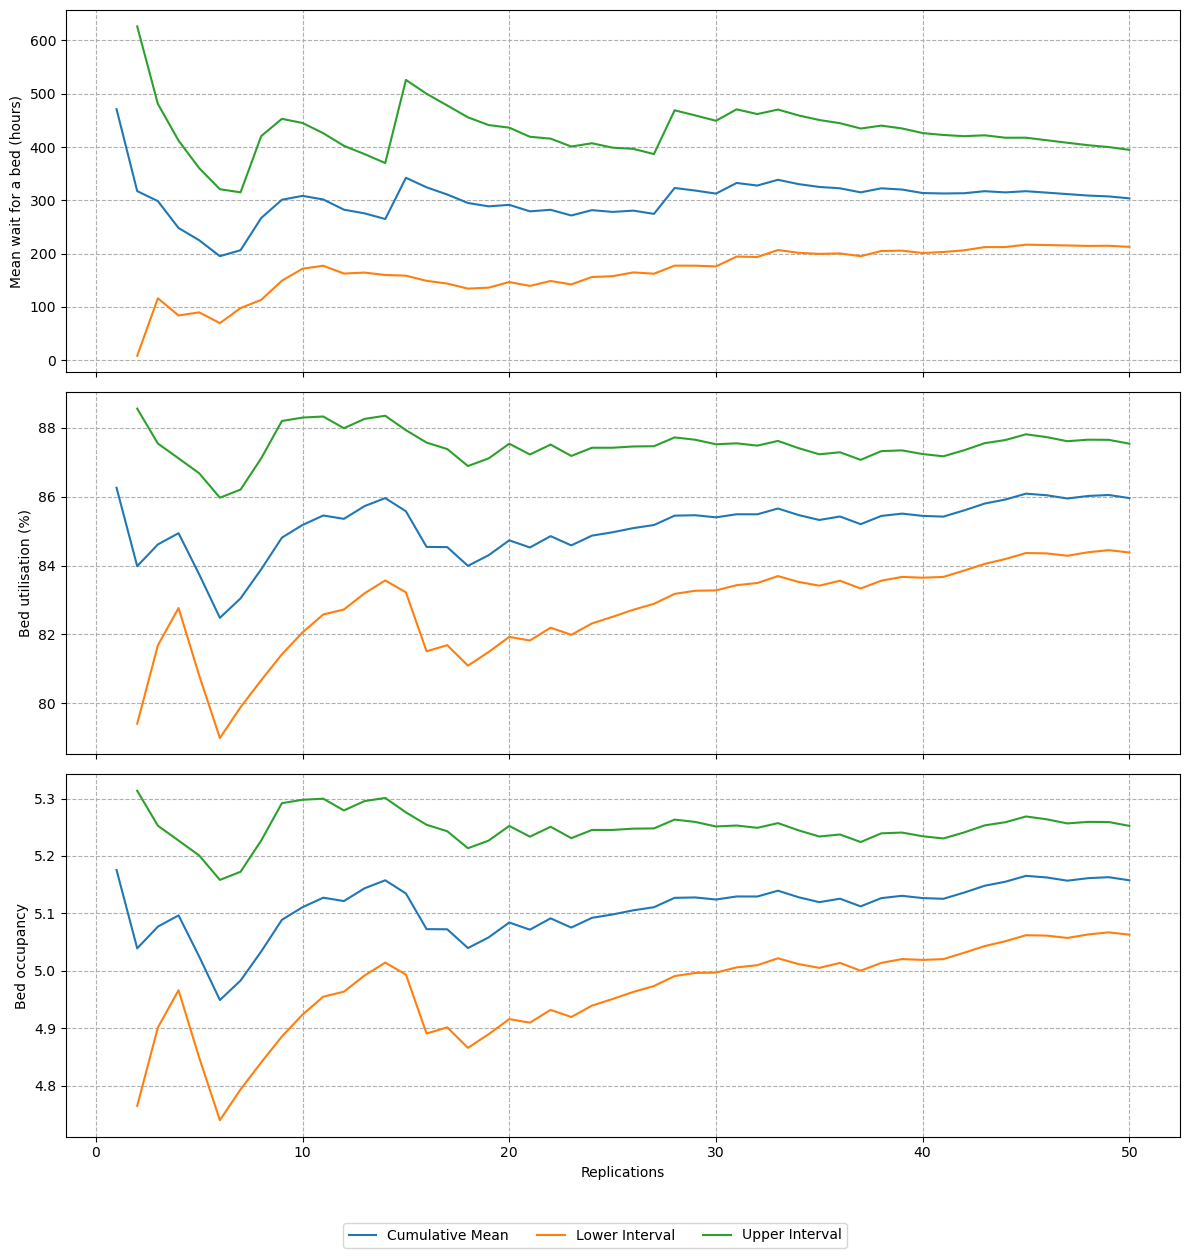

In [17]:
print("Six Beds")
six_beds_plot = beds_experiment.trial_objects["Six Beds"].plot_reps()
beds_experiment.trial_objects["Six Beds"].overall_results_df

Eight Beds


,Mean,Standard Deviation
Mean Wait for a Bed,47.669972,103.426415
Bed Utilisation,67.980124,7.381995
Bed Occupancy,5.438410,0.590560


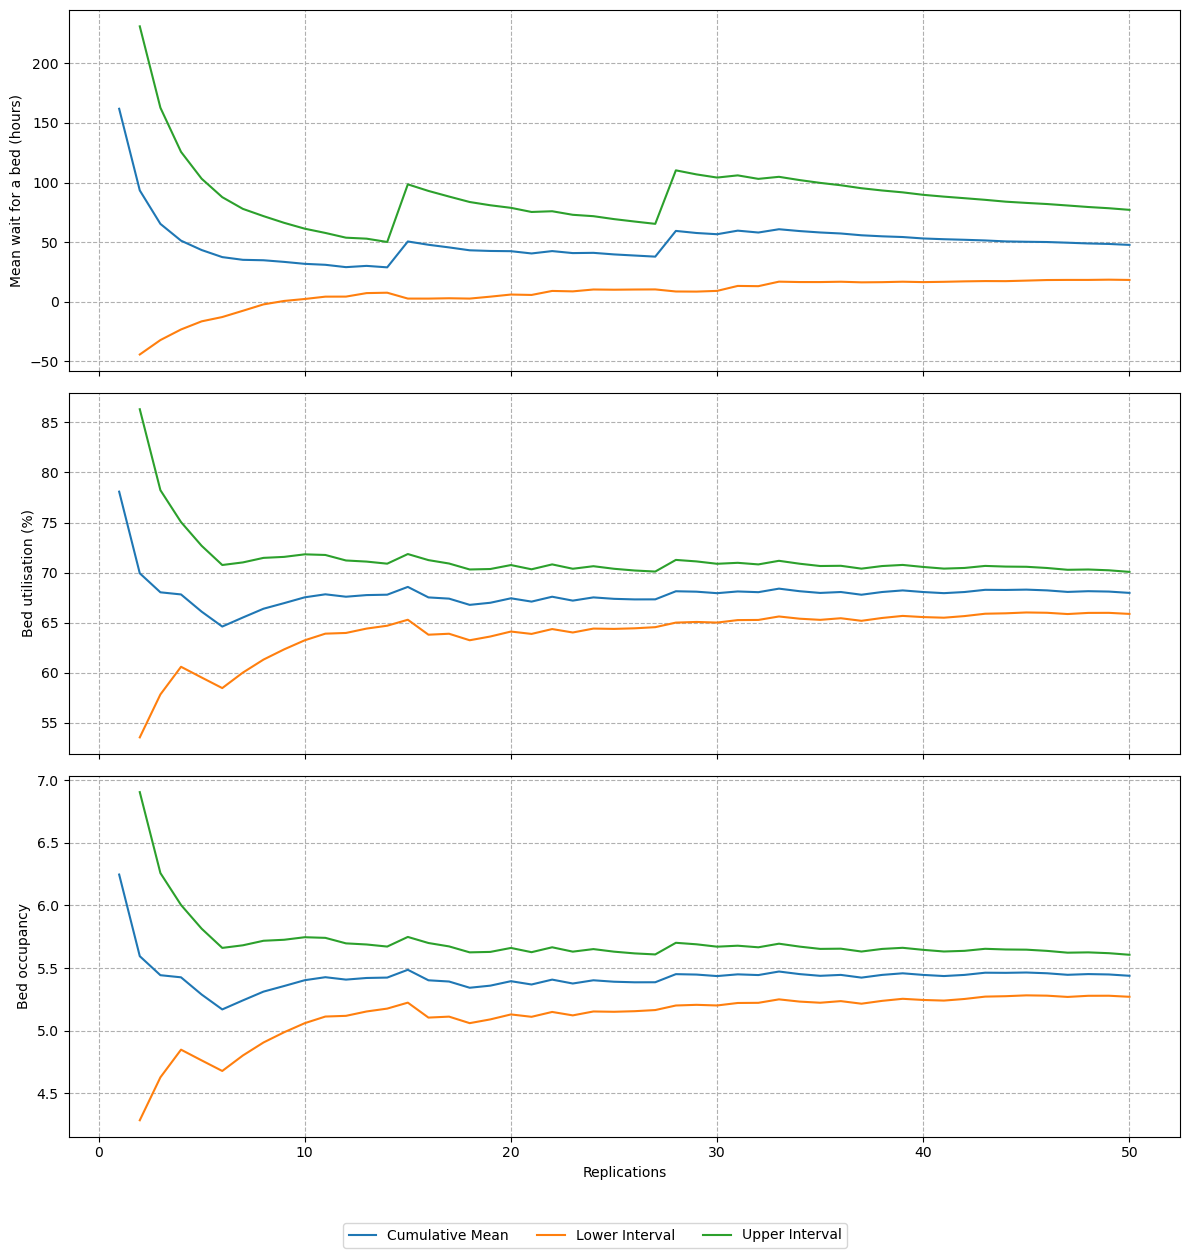

In [18]:
print("Eight Beds")
eight_beds_plot = beds_experiment.trial_objects["Eight Beds"].plot_reps()
beds_experiment.trial_objects["Eight Beds"].overall_results_df

Ten Beds


,Mean,Standard Deviation
Mean Wait for a Bed,5.565093,13.861921
Bed Utilisation,54.547942,6.121904
Bed Occupancy,5.454794,0.612190


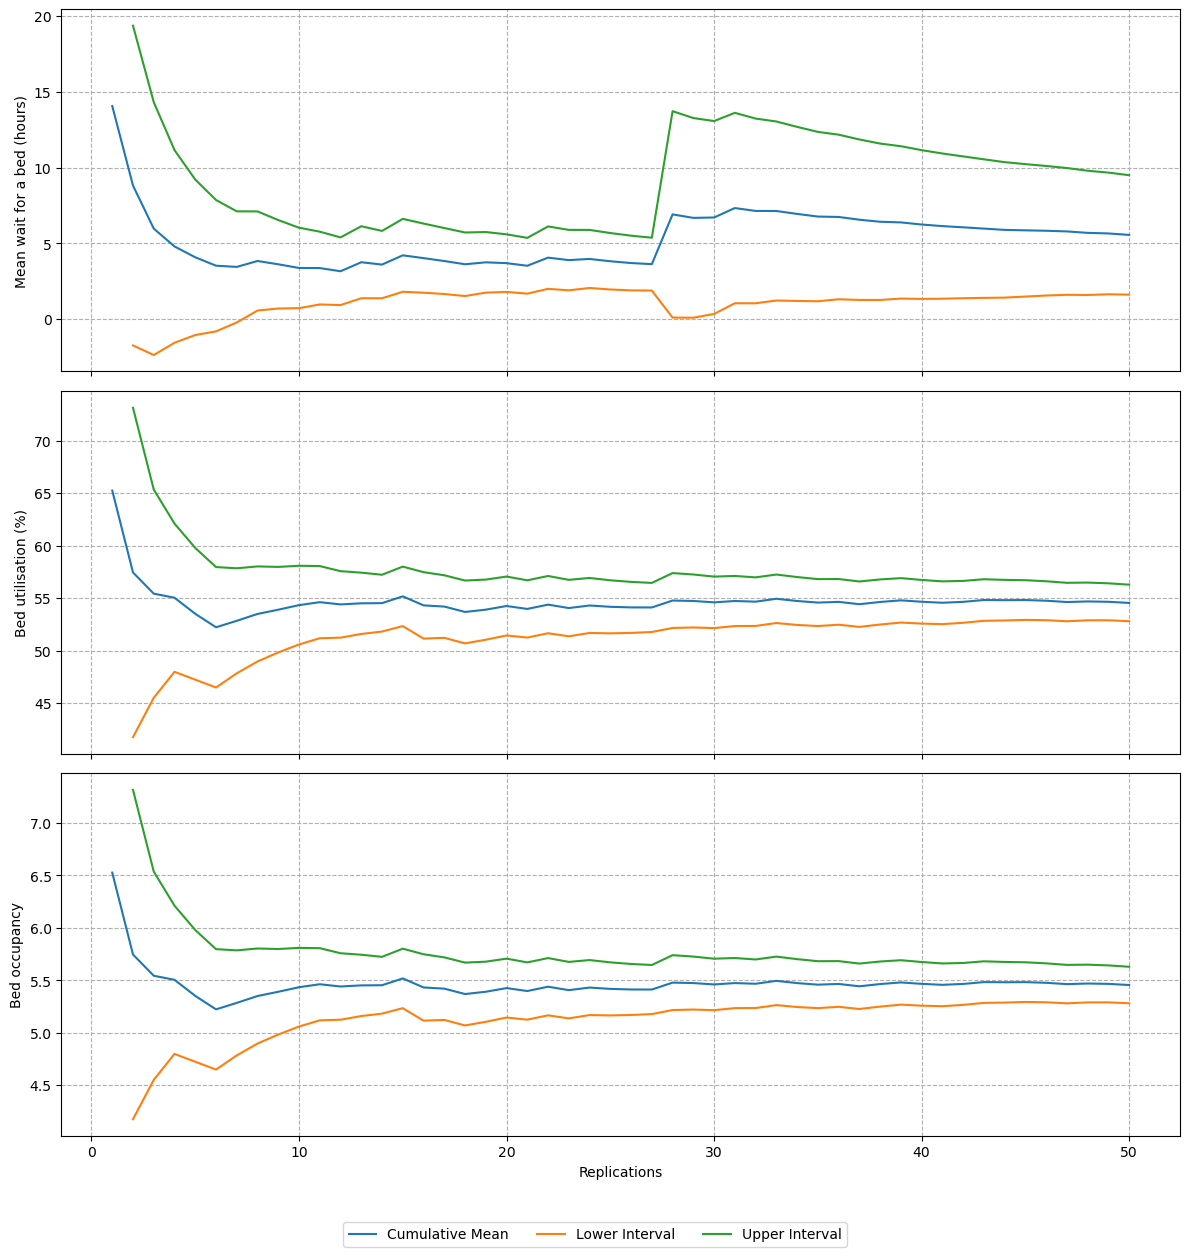

In [19]:
print("Ten Beds")
ten_beds_plot = beds_experiment.trial_objects["Ten Beds"].plot_reps()
beds_experiment.trial_objects["Ten Beds"].overall_results_df